Please refer to the GitHub readme for supporting information.
Link: https://github.com/yashjswl/earth_observation

Q1. SPATIAL REASONING AND DATA FILTERING
Importing Libraries and Dependedncies

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import math
from shapely.geometry import box
import os
import rasterio
from rasterio.windows import Window
from sklearn.model_selection import train_test_split

Plot the Delhi-NCR shapefile using matplotlib and overlay a 60×60 km uniform grid

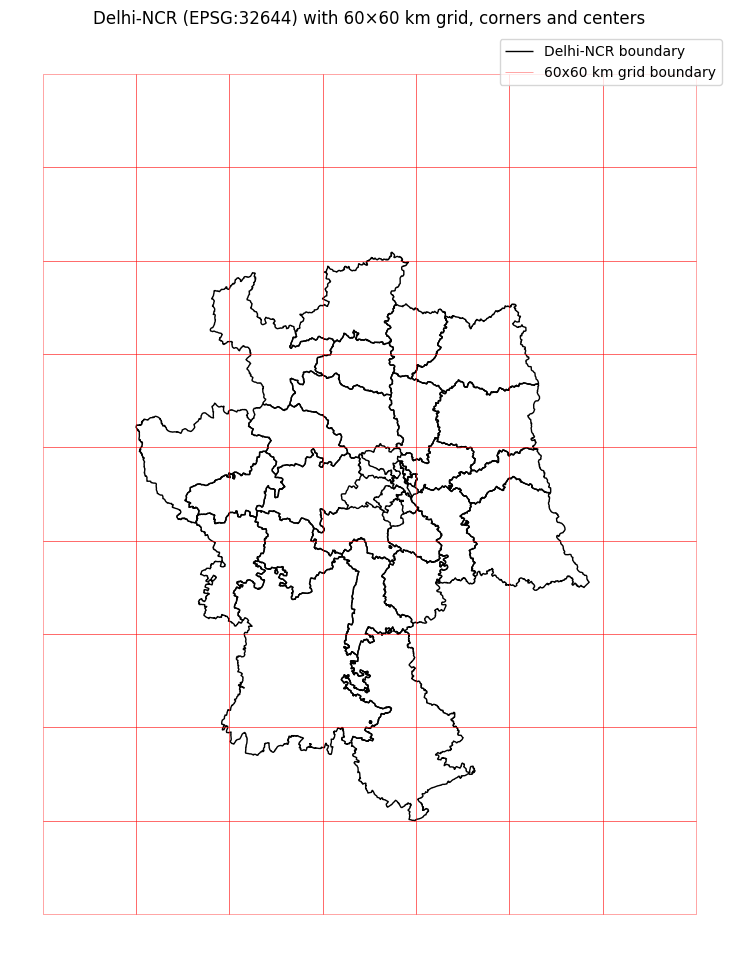

In [2]:
SF="/Users/yashasvi/Desktop/earth_observation/Assets/delhi_ncr_region.geojson"
gdf=gpd.read_file(SF)
gdf_new = gdf.to_crs(epsg=32644)

cell_size = 60000
minx, miny, maxx, maxy = gdf_new.total_bounds
minx -= cell_size; miny -= cell_size; maxx += cell_size; maxy += cell_size

cols = list(range(int(math.floor(minx)), int(math.ceil(maxx)), cell_size))
rows = list(range(int(math.floor(miny)), int(math.ceil(maxy)), cell_size))
grid_polys = []
for x0 in cols:
    for y0 in rows:
        x1 = x0 + cell_size
        y1 = y0 + cell_size
        grid_polys.append(box(x0, y0, x1, y1))
grid_gdf = gpd.GeoDataFrame({"geometry": grid_polys}, crs="EPSG:32644")

fig, ax = plt.subplots(figsize=(12,12))
gdf_new.boundary.plot(ax=ax, linewidth=1, edgecolor="black", label="Delhi-NCR boundary")
grid_gdf.boundary.plot(ax=ax, linewidth=0.5, edgecolor="red", alpha=0.5, label="60x60 km grid boundary")
ax.set_title("Delhi-NCR (EPSG:32644) with 60×60 km grid, corners and centers")
ax.set_axis_off()
ax.legend()
plt.show()

Filter satellite images whose center coordinates fall inside the region.
Report the total number of images before and after filtering.

In [3]:
IMAGE_FOLDER = "/Users/yashasvi/Desktop/earth_observation/Assets/rgb"

files = [f for f in os.listdir(IMAGE_FOLDER)]
rows = []

for fn in files:
    base = os.path.splitext(fn)[0]
    try:
        lat_str, lon_str = base.split("_")
        rows.append({"filename": fn, "latitude": float(lat_str), "longitude": float(lon_str)})
    except ValueError:
        continue

df_img = pd.DataFrame(rows)

images_gdf = gpd.GeoDataFrame(
    df_img,
    geometry=gpd.points_from_xy(df_img.longitude, df_img.latitude),
    crs="EPSG:4326"
)
images_proj = images_gdf.to_crs(epsg=32644)

filtered_images_gdf = gpd.sjoin(images_proj, gdf_new, predicate='within')

print("Number of images before filtering:", len(df_img))
print("Number of images after filtering:", len(filtered_images_gdf))

Number of images before filtering: 9216
Number of images after filtering: 8015


Q2. Label Construction & Dataset Preparation
For each image, extract the  128×128 corresponding land-cover patch from land_cover.tif using its center coordinate

For each image, extract the  128×128 corresponding land-cover patch from land_cover.tif using its center coordinate.
Assign the image label using the dominant (mode) land-cover class.
Map ESA class codes to simplified land-use categories (e.g., Built-up, Vegetation, Water, Cropland, Others).

In [4]:
LC_PATH = "/Users/yashasvi/Desktop/earth_observation/Assets/worldcover_bbox_delhi_ncr_2021.tif"
esa_mapping = {
    10: "Vegetation", 20: "Vegetation", 30: "Vegetation", 90: "Vegetation", 95: "Vegetation",
    40: "Cropland",
    50: "Built-up",
    80: "Water",
    60: "Others", 70: "Others", 100: "Others", 0: "Others"
}
labels = []
simplified_labels = []

with rasterio.open(LC_PATH) as src:
    gdf_lc = filtered_images_gdf.to_crs(src.crs)
    
    for geom in gdf_lc.geometry:
        row, col = src.index(geom.x, geom.y)
        window = Window(col - 64, row - 64, 128, 128)
        patch = src.read(1, window=window)
        
        if patch.size > 0:
            values, counts = np.unique(patch, return_counts=True)
            dominant_class = values[np.argmax(counts)]
        else:
            dominant_class = 0
            
        labels.append(dominant_class)
        simplified_labels.append(esa_mapping.get(dominant_class, "Others"))
filtered_images_gdf['label_code'] = labels
filtered_images_gdf['label_name'] = simplified_labels

Perform a 60/40 train-test split randomly and visualize class distribution

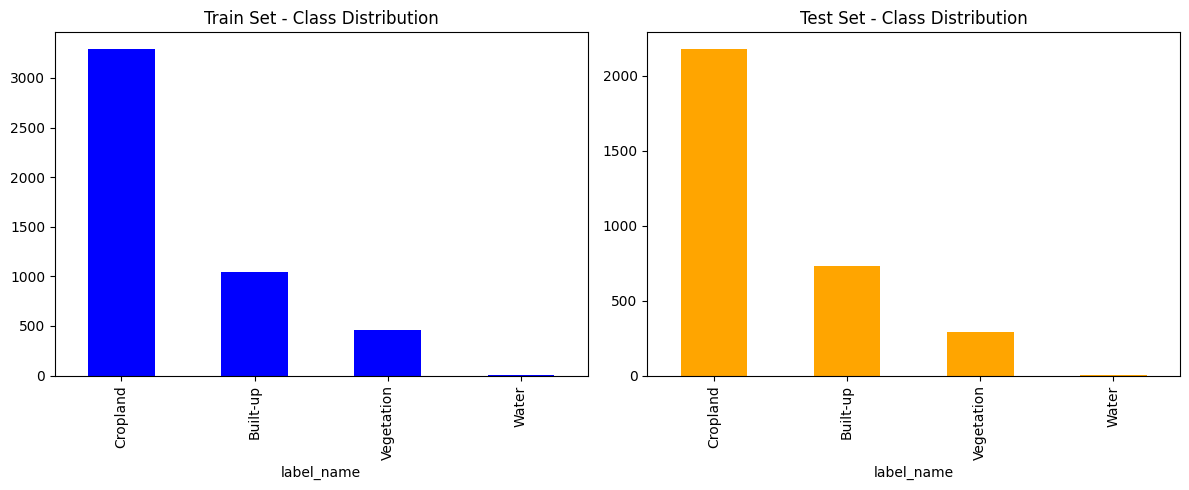

In [5]:
train_df, test_df = train_test_split(filtered_images_gdf, test_size=0.40, random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
train_df['label_name'].value_counts().plot(kind='bar', ax=ax[0], color='blue', title='Train Set - Class Distribution')
test_df['label_name'].value_counts().plot(kind='bar', ax=ax[1], color='orange', title='Test Set - Class Distribution')
plt.tight_layout()
plt.show()

Visualization of simplified land-use categories using Google Earth Engine.

In [6]:
import geemap
import ee
ee.Initialize()

Map = geemap.Map()
Map.add_basemap("SATELLITE")
color_map={"Vegetation":"green","Cropland":"yellow","Built-up":"red","Water":"blue","Others":"gray"}
for label in filtered_images_gdf['label_name'].unique():
    Map.addLayer(geemap.geopandas_to_ee(filtered_images_gdf[filtered_images_gdf['label_name']==label].to_crs(epsg=4326)),{'color':color_map.get(label,'black')},label)
Map.centerObject(geemap.geopandas_to_ee(filtered_images_gdf.to_crs(epsg=4326)),9)
Map

Map(center=[28.59154830461165, 77.27771734667816], controls=(WidgetControl(options=['position', 'transparent_b…

Q3. Model Training & Supervised Evaluation.
Train a CNN model for land-use classification. (FasterNet Used)

In [7]:
import torch, timm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Mapping text labels to 0-indexed IDs
s_labels = sorted(train_df['label_name'].unique())
lbl2id = {l: i for i, l in enumerate(s_labels)}
train_df['label_id'] = train_df['label_name'].map(lbl2id)
test_df['label_id'] = test_df['label_name'].map(lbl2id)

class LandCoverDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(f"{self.img_dir}/{self.df.loc[idx, 'filename']}").convert("RGB")
        return self.transform(img), self.df.loc[idx, 'label_id']

tf_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tf_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(LandCoverDataset(train_df, IMAGE_FOLDER, tf_train), batch_size=32, shuffle=True)
test_loader = DataLoader(LandCoverDataset(test_df, IMAGE_FOLDER, tf_test), batch_size=32, shuffle=False)

#FasterNet Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('fasternet_t0', pretrained=True, num_classes=len(s_labels)).to(device)
crit = nn.CrossEntropyLoss()
opt = optim.AdamW(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt.zero_grad()
        crit(model(imgs), lbls).backward()
        opt.step()

Evaluate using accuracy and F1-score.

In [8]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        y_true.extend(lbls.numpy())
        y_pred.extend(model(imgs.to(device)).argmax(1).cpu().numpy())

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")

Accuracy: 0.9080
F1-Score: 0.9065


Display a confusion matrix and briefly interpret the results.

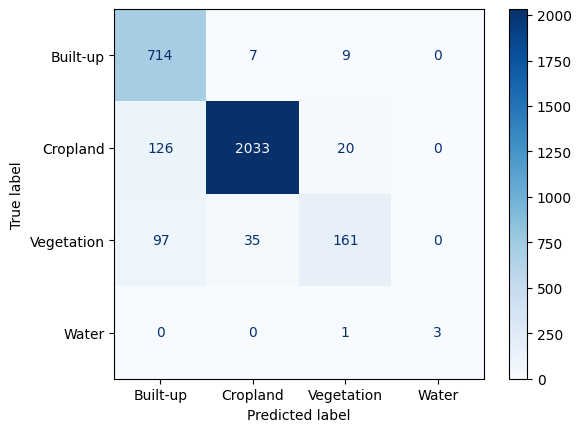

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=s_labels)
disp.plot(cmap='Blues')
plt.show()